# Milestone 4 Objective

Build the RAG Knowledge Agent as a standalone local indexing and retrieval agent.

## RAG Knowledge Agent Role

The agent reads selected repository files, creates chunks, embeds them with deterministic local hash vectors, saves a local vector index, and retrieves relevant context for a testing query.

## Why RAG Works Alone Before The Test Planner

The Test Planner should later consume grounded repository context. This milestone proves that context retrieval works before any test generation is attempted.

## RAG Pipeline

```text
documents -> chunks -> local vectors -> vector store -> retrieval context
```

## Mini LangGraph Workflow

```text
START -> rag -> END
```

## What The RAG Agent Writes To State

The RAG Agent writes `rag_index_path`, `rag_query`, `retrieved_context`, and `missing_information`. The full vector index stays on disk under `results/runs/<run_id>/rag_index/`.

## Security Note

RAG reads repository text files but does not execute target code, does not run the Django server, does not use MCP, and does not call LLM APIs.

## Target Repository

https://github.com/Vitaee/DjangoRestAPI

## Part A - Offline Fake Repo RAG

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

from test_auto.agents.rag_agent import run_rag_agent_alone

In [2]:
from tempfile import TemporaryDirectory

tmp = TemporaryDirectory()
fake_repo_path = Path(tmp.name) / "fake_rag_repo"

def write_file(relative_path: str, content: str = "") -> None:
    path = fake_repo_path / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")

write_file("README.md", "# Todo API\nJWT authentication protects Todo CRUD API routes.\n")
write_file("requirements.txt", "django\ndjangorestframework\ndjangorestframework-simplejwt\n")
write_file("todo/urls.py", 'path("api/todos/", views.todo_list)\n')
write_file("todo/views.py", "def list_todos(request): pass\ndef create_todo(request): pass\ndef update_todo(request): pass\ndef delete_todo(request): pass\n")
write_file("templates/login.html", "<form>JWT login</form>\n")
write_file("tests/test_todo_api.py", "def test_todo_list(): assert True\n")

project_info = {
    "language": "Python",
    "framework": "Django REST Framework",
    "has_api": True,
    "has_ui": True,
    "auth_type": "JWT",
    "candidate_docs": ["README.md"],
    "candidate_api_files": ["todo/urls.py", "todo/views.py"],
    "candidate_ui_files": ["templates/login.html"],
    "test_dirs": ["tests/test_todo_api.py"],
}

fake_repo_path

WindowsPath('C:/Users/malak/AppData/Local/Temp/tmpev2qmq5l/fake_rag_repo')

In [3]:
rag_result = run_rag_agent_alone(
    repo_path=str(fake_repo_path),
    project_info=project_info,
    query="JWT authentication todo CRUD API tests",
)

In [4]:
import json

print(json.dumps({
    "rag_query": rag_result["rag_query"],
    "chunk_count": rag_result["chunk_count"],
    "retrieved_context": rag_result["retrieved_context"],
    "missing_information": rag_result["missing_information"],
    "rag_index_path": rag_result["rag_index_path"],
    "retrieved_context_path": rag_result["retrieved_context_path"],
}, indent=2))

{
  "rag_query": "JWT authentication todo CRUD API tests",
  "chunk_count": 8,
  "retrieved_context": [
    {
      "chunk_id": "readme_md_0_eb955f0b582d",
      "source_path": "README.md",
      "content": "# Todo API\nJWT authentication protects Todo CRUD API routes.",
      "score": 0.7925939239012172,
      "reason": "Matched query terms related to api, authentication, crud, jwt, todo.",
      "chunk_type": "doc",
      "metadata": {
        "repo_path": "C:\\Users\\malak\\AppData\\Local\\Temp\\tmpev2qmq5l\\fake_rag_repo",
        "split_strategy": "markdown_heading"
      }
    },
    {
      "chunk_id": "todo_urls_py_0_e85229e77d0d",
      "source_path": "todo/urls.py",
      "content": "path(\"api/todos/\", views.todo_list)",
      "score": 0.1825741858350554,
      "reason": "Matched query terms related to api.",
      "chunk_type": "api",
      "metadata": {
        "repo_path": "C:\\Users\\malak\\AppData\\Local\\Temp\\tmpev2qmq5l\\fake_rag_repo",
        "split_strategy": "py

## Part B - Optional Real Target Repository

The next cell requires internet and `git`. It clones files for analysis only; it does not run the Django project.

In [5]:
target_repo_url = "https://github.com/Vitaee/DjangoRestAPI"
RUN_REAL_TARGET = False

if RUN_REAL_TARGET:
    real_rag_result = run_rag_agent_alone(
        repo_url=target_repo_url,
        query="JWT authentication todo CRUD API tests",
    )
    print(json.dumps({
        "retrieved_context": real_rag_result["retrieved_context"],
        "rag_result_json": real_rag_result["agent_output_path"],
        "retrieved_context_json": real_rag_result["retrieved_context_path"],
        "manifest_json": str(Path(real_rag_result["rag_index_path"]) / "manifest.json"),
    }, indent=2))
else:
    print("Set RUN_REAL_TARGET = True to clone and analyze the GitHub repository.")

Set RUN_REAL_TARGET = True to clone and analyze the GitHub repository.


## Part C - Mini LangGraph Workflow

In [6]:
from test_auto.graph.rag_workflow import run_rag_workflow

rag_state = run_rag_workflow({
    "run_id": "notebook_rag_workflow",
    "repo_path": str(fake_repo_path),
    "project_info": project_info,
    "rag_query": "JWT authentication todo CRUD API tests",
    "errors": [],
    "agent_logs": [],
})
print(json.dumps(rag_state, indent=2))

{
  "run_id": "notebook_rag_workflow",
  "errors": [],
  "agent_logs": [
    {
      "agent": "rag",
      "timestamp": "2026-05-20T08:40:26.909912+00:00",
      "status": "success",
      "duration_seconds": 0.04199769999831915,
      "query": "JWT authentication todo CRUD API tests",
      "index_path": "results\\runs\\notebook_rag_workflow\\rag_index",
      "chunk_count": 8,
      "retrieved_context": [
        {
          "chunk_id": "readme_md_0_eb955f0b582d",
          "source_path": "README.md",
          "content": "# Todo API\nJWT authentication protects Todo CRUD API routes.",
          "score": 0.7925939239012172,
          "reason": "Matched query terms related to api, authentication, crud, jwt, todo.",
          "chunk_type": "doc",
          "metadata": {
            "repo_path": "C:\\Users\\malak\\AppData\\Local\\Temp\\tmpev2qmq5l\\fake_rag_repo",
            "split_strategy": "markdown_heading"
          }
        },
        {
          "chunk_id": "todo_urls_py_0_e852

## Part D - Graph Visualization

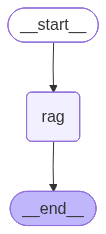

In [7]:
from test_auto.graph.rag_workflow import build_rag_graph

graph = build_rag_graph()
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    try:
        print(graph.get_graph().draw_mermaid())
    except Exception:
        print("Graph: START -> rag -> END")
        print(f"Visualization error: {exc}")